# Premier League Match Outcome Prediction

Predicting English Premier League match results (Home Win / Draw / Away Win) from pre-match information only — recent form, scoring history, and points accumulated before kickoff. Built on 5 seasons of match data (2021-2026, ~1,900 matches) from football-data.co.uk.

**Key result:** Random Forest and XGBoost both beat a majority-class baseline by a statistically meaningful margin under 5-fold cross-validation (~48-50% vs. 44.6% baseline), though neither reliably detects draws — a known-hard sub-problem in football prediction, discussed in Results below.

The focus here is on validating that result properly — cross-validation instead of a single lucky/unlucky split, and an honest look at where the model actually fails — rather than just reporting a headline number.

In [1]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    cross_val_predict
)

from sklearn.dummy import DummyClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")


## Data

Five seasons of EPL match data, loaded and concatenated.

In [3]:
df1 = pd.read_csv("2021-22.csv")
df2 = pd.read_csv("2022-23.csv")
df3 = pd.read_csv("2023-24.csv")
df4 = pd.read_csv("2024-25.csv")
df5 = pd.read_csv("2025-26.csv")

In [4]:
df = pd.concat([df1, df2, df3, df4, df5], ignore_index=True)

In [5]:
df.describe()

,FTHG,FTAG,HTHG,HTAG,HS,AS,HST,AST,HF,AF,...,IWA,VCH,VCD,VCA,IWCH,IWCD,IWCA,VCCH,VCCD,VCCA
count,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000,...,958.000000,1140.000000,1140.000000,1140.000000,955.000000,955.000000,955.000000,1140.000000,1140.000000,1140.000000
mean,1.597368,1.329474,0.724211,0.577368,14.158947,11.710526,4.872105,4.121053,10.567895,10.940526,...,4.461806,2.968781,4.169965,4.744614,2.923382,4.142513,4.407864,3.022596,4.271491,4.823360
std,1.318038,1.204203,0.849212,0.791485,5.657133,5.171355,2.567870,2.374181,3.418828,3.576905,...,3.824660,2.382891,1.336713,4.505495,2.105826,1.227982,3.606997,2.473200,1.467024,4.558426
min,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.150000,1.060000,2.900000,1.110000,1.080000,2.950000,1.150000,1.060000,2.880000,1.120000
25%,1.000000,0.000000,0.000000,0.000000,10.000000,8.000000,3.000000,2.000000,8.000000,8.000000,...,2.200000,1.620000,3.400000,2.150000,1.650000,3.400000,2.200000,1.620000,3.400000,2.150000
50%,1.000000,1.000000,1.000000,0.000000,14.000000,11.000000,5.000000,4.000000,10.000000,11.000000,...,3.150000,2.225000,3.700000,3.165000,2.300000,3.700000,3.200000,2.250000,3.750000,3.300000
75%,2.000000,2.000000,1.000000,1.000000,18.000000,15.000000,6.000000,5.000000,13.000000,13.000000,...,5.250000,3.250000,4.400000,5.500000,3.300000,4.400000,5.250000,3.400000,4.500000,5.500000
max,9.000000,8.000000,5.000000,5.000000,36.000000,37.000000,16.000000,15.000000,23.000000,25.000000,...,28.000000,19.000000,11.500000,31.000000,19.000000,12.000000,27.000000,26.000000,15.000000,41.000000


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1900 entries, 0 to 1899
Columns: 162 entries, Div to VCCA
dtypes: float64(138), int64(16), str(8)
memory usage: 2.3 MB


The raw files carry 160+ columns, most of which are bookmaker odds (Bet365, Pinnacle, Betfair, etc.) and match-official data. These are dropped here — the goal is to predict outcomes from team performance signals alone, not from market prices. A natural extension is benchmarking this model's accuracy against the market's own implied probability (see Limitations).

In [7]:
useful_columns = [
    "Date","HomeTeam","AwayTeam",
    "FTHG","FTAG","FTR",
    "HS","AS","HST","AST",
    "HC","AC","HF","AF",
    "HY","AY","HR","AR"
]

match_df = df[useful_columns].copy()

In [8]:
match_df.isnull().sum()

Date        0
HomeTeam    0
AwayTeam    0
FTHG        0
FTAG        0
FTR         0
HS          0
AS          0
HST         0
AST         0
HC          0
AC          0
HF          0
AF          0
HY          0
AY          0
HR          0
AR          0
dtype: int64

## Exploratory Data Analysis

In [9]:
match_df["FTR"].value_counts()

FTR
H    839
A    607
D    454
Name: count, dtype: int64

In [10]:
(match_df["FTR"].value_counts(normalize=True) * 100).round(2)

FTR
H    44.16
A    31.95
D    23.89
Name: proportion, dtype: float64

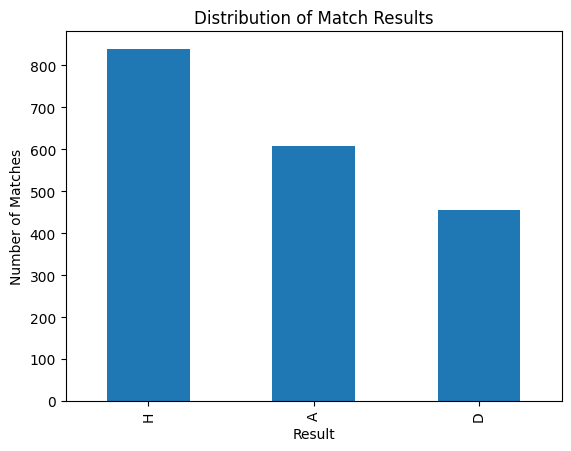

In [11]:
match_df["FTR"].value_counts().plot(kind="bar")

plt.title("Distribution of Match Results")
plt.xlabel("Result")
plt.ylabel("Number of Matches")
plt.show()

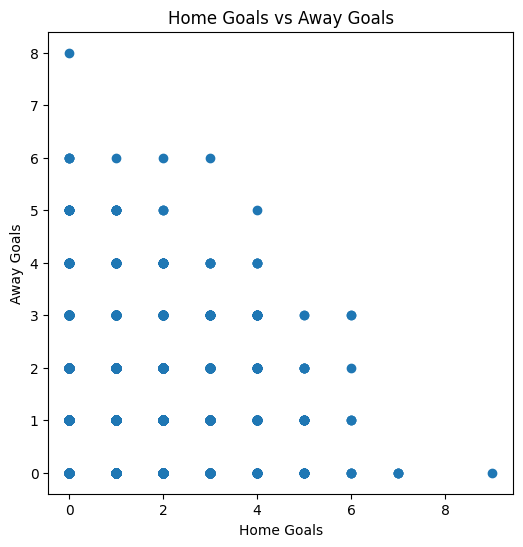

In [12]:
plt.figure(figsize=(6,6))

plt.scatter(match_df["FTHG"], match_df["FTAG"])

plt.xlabel("Home Goals")
plt.ylabel("Away Goals")
plt.title("Home Goals vs Away Goals")

plt.show()

In [13]:
match_df["TotalGoals"] = match_df["FTHG"] + match_df["FTAG"]

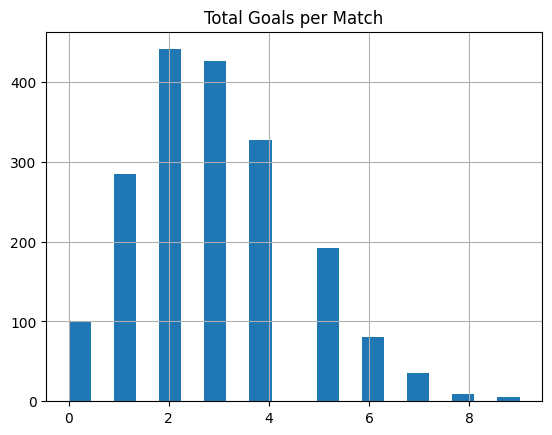

In [14]:
match_df["TotalGoals"].hist(bins=20)

plt.title("Total Goals per Match")
plt.show()

In [15]:
match_df["Date"] = pd.to_datetime(match_df["Date"], dayfirst=True)

match_df["Year"] = match_df["Date"].dt.year
match_df["Month"] = match_df["Date"].dt.month
match_df["Day"] = match_df["Date"].dt.day
match_df["Weekday"] = match_df["Date"].dt.day_name()

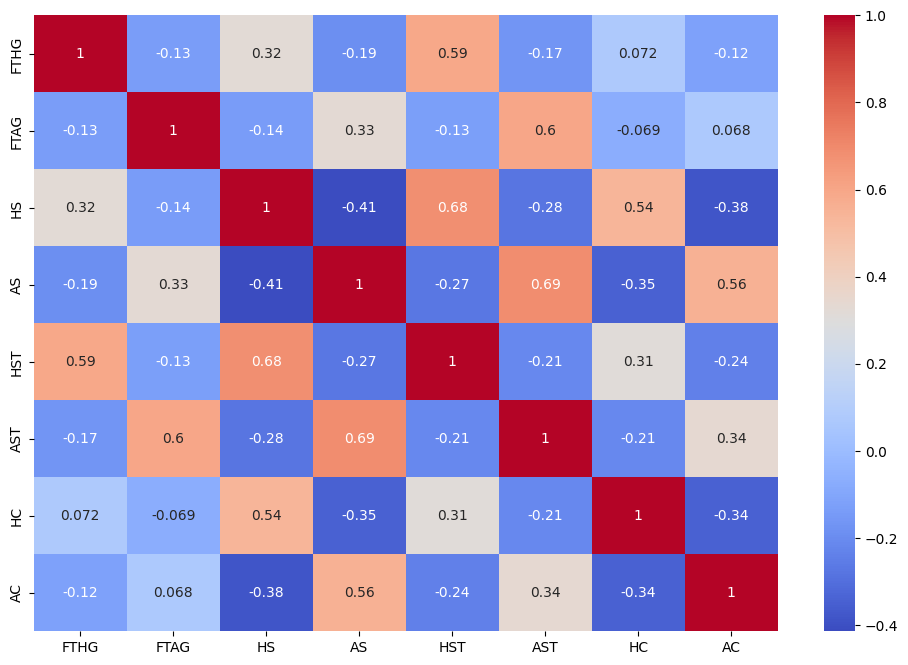

In [16]:
plt.figure(figsize=(12,8))

sns.heatmap(
    match_df[["FTHG","FTAG","HS","AS","HST","AST","HC","AC"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

## Feature Engineering

All features are built from information available before kickoff only — form, scoring, and
points from each team's previous matches. Two design choices matter here:

- **`shift(1)` before `rolling(5)`** — every rolling window explicitly excludes the current
  match before computing rolling stats, so a team's "form" feature for a given match never
  includes that match's own result. This avoids leaking the outcome into the inputs, a common
  bug in match-prediction projects that use in-game stats (shots, corners, cards) directly —
  those are only known after kickoff and correlate strongly with the result, so they're
  excluded from the feature set entirely.
- **Team-level, not just home-level, form** — matches are restructured into one row per team
  per match (`team_df`) so a team's rolling form reflects *all* of their recent matches, home
  and away, not just their home form or away form in isolation.

In [17]:
match_df = match_df.sort_values("Date")
match_df = match_df.reset_index(drop=True)

In [18]:
match_df["HomePoints"] = np.where(
    match_df["FTR"] == "H",
    3,
    np.where(match_df["FTR"] == "A", 0, 1)
)

In [19]:
match_df["AwayPoints"] = np.where(
    match_df["FTR"] == "A",
    3,
    np.where(match_df["FTR"] == "H", 0, 1)
)

In [20]:
home_df = match_df[[
    "Date",
    "HomeTeam",
    "AwayTeam",
    "HomePoints",
    "FTHG",
    "FTAG",
    "HST",
    "AST"
]].copy()

home_df.columns = [
    "Date",
    "Team",
    "Opponent",
    "Points",
    "GoalsScored",
    "GoalsConceded",
    "ShotsOnTargetFor",
    "ShotsOnTargetAgainst"
]

In [21]:
away_df = match_df[[
    "Date",
    "AwayTeam",
    "HomeTeam",
    "AwayPoints",
    "FTAG",
    "FTHG",
    "AST",
    "HST"
]].copy()

away_df.columns = [
    "Date",
    "Team",
    "Opponent",
    "Points",
    "GoalsScored",
    "GoalsConceded",
    "ShotsOnTargetFor",
    "ShotsOnTargetAgainst"
]

In [22]:
team_df = pd.concat([home_df, away_df], ignore_index=True)

In [23]:
team_df = team_df.sort_values(["Team", "Date"])
team_df = team_df.reset_index(drop=True)

In [24]:
team_df["Last5Points"] = (
    team_df.groupby("Team")["Points"]
           .shift(1)
           .rolling(5)
           .sum()
)

In [25]:
team_df["Last5GoalsScored"] = (
    team_df.groupby("Team")["GoalsScored"]
           .shift(1)
           .rolling(5)
           .sum()
)

In [26]:
team_df["Last5GoalsConceded"] = (
    team_df.groupby("Team")["GoalsConceded"]
           .shift(1)
           .rolling(5)
           .sum()
)

Quick check: the first five matches for any team show `NaN` for `Last5Points`, since there isn't a five-match history to roll over yet — confirming the feature can't peek at future or same-match information.

In [27]:
team_df[team_df["Team"]=="Liverpool"][
    ["Date","Points","Last5Points"]
].head(15)

,Date,Points,Last5Points
2014,2021-08-14,3,NaN
2015,2021-08-21,3,NaN
2016,2021-08-28,1,NaN
2017,2021-09-12,3,NaN
2018,2021-09-18,3,NaN
2019,2021-09-25,1,13.0
2020,2021-10-03,1,11.0
2021,2021-10-16,3,9.0
2022,2021-10-24,3,11.0
2023,2021-10-30,1,11.0


In [28]:
match_df = match_df.merge(
    team_df[[
        "Date",
        "Team",
        "Last5Points",
        "Last5GoalsScored",
        "Last5GoalsConceded"
    ]],
    left_on=["Date", "HomeTeam"],
    right_on=["Date", "Team"],
    how="left"
)

In [29]:
match_df.rename(columns={
    "Last5Points": "HomeLast5Points",
    "Last5GoalsScored": "HomeLast5GoalsScored",
    "Last5GoalsConceded": "HomeLast5GoalsConceded"
}, inplace=True)

In [30]:
match_df.drop(columns=["Team"], inplace=True)

In [31]:
match_df = match_df.merge(
    team_df[[
        "Date",
        "Team",
        "Last5Points",
        "Last5GoalsScored",
        "Last5GoalsConceded"
    ]],
    left_on=["Date", "AwayTeam"],
    right_on=["Date", "Team"],
    how="left"
)

In [32]:
match_df.rename(columns={
    "Last5Points": "AwayLast5Points",
    "Last5GoalsScored": "AwayLast5GoalsScored",
    "Last5GoalsConceded": "AwayLast5GoalsConceded"
}, inplace=True)

In [33]:
match_df.drop(columns=["Team"], inplace=True)

In [34]:
match_df = match_df.dropna()
match_df.reset_index(drop=True, inplace=True)

In [35]:
match_df["FTR"] = match_df["FTR"].map({
    "H": 0,
    "D": 1,
    "A": 2
})

In [36]:
match_df["FTR"].value_counts()

FTR
0    799
2    584
1    432
Name: count, dtype: int64

In [37]:
team_df["Last5GoalDifference"] = (
    team_df["Last5GoalsScored"] -
    team_df["Last5GoalsConceded"]
)

In [38]:
match_df = match_df.merge(
    team_df[["Date", "Team", "Last5GoalDifference"]],
    left_on=["Date", "HomeTeam"],
    right_on=["Date", "Team"],
    how="left"
)

match_df.rename(
    columns={"Last5GoalDifference": "HomeLast5GoalDifference"},
    inplace=True
)

match_df.drop(columns=["Team"], inplace=True)

In [39]:
match_df = match_df.merge(
    team_df[["Date", "Team", "Last5GoalDifference"]],
    left_on=["Date", "AwayTeam"],
    right_on=["Date", "Team"],
    how="left"
)

match_df.rename(
    columns={"Last5GoalDifference": "AwayLast5GoalDifference"},
    inplace=True
)

match_df.drop(columns=["Team"], inplace=True)

In [40]:
team_df["MatchesPlayed"] = team_df.groupby("Team").cumcount()

In [41]:
team_df["PreviousTotalPoints"] = (
    team_df.groupby("Team")["Points"]
           .transform(lambda x: x.cumsum().shift(1))
)

In [42]:
team_df["AvgPointsPerGame"] = np.where(
    team_df["MatchesPlayed"] > 0,
    team_df["PreviousTotalPoints"] / team_df["MatchesPlayed"],
    np.nan
)

In [43]:
match_df = match_df.merge(
    team_df[["Date", "Team", "AvgPointsPerGame"]],
    left_on=["Date", "HomeTeam"],
    right_on=["Date", "Team"],
    how="left"
)

match_df.rename(
    columns={"AvgPointsPerGame": "HomeAvgPointsPerGame"},
    inplace=True
)

match_df.drop(columns=["Team"], inplace=True)

In [44]:
match_df = match_df.merge(
    team_df[["Date", "Team", "AvgPointsPerGame"]],
    left_on=["Date", "AwayTeam"],
    right_on=["Date", "Team"],
    how="left"
)

match_df.rename(
    columns={"AvgPointsPerGame": "AwayAvgPointsPerGame"},
    inplace=True
)

match_df.drop(columns=["Team"], inplace=True)

In [45]:
home_df = home_df.sort_values(["Team", "Date"]).reset_index(drop=True)

In [46]:
home_df["HomeLast5HomePoints"] = (
    home_df.groupby("Team")["Points"]
           .transform(lambda x: x.shift(1).rolling(5).sum())
)

In [47]:
away_df = away_df.sort_values(["Team", "Date"]).reset_index(drop=True)

In [48]:
away_df["AwayLast5AwayPoints"] = (
    away_df.groupby("Team")["Points"]
           .transform(lambda x: x.shift(1).rolling(5).sum())
)

In [49]:
match_df = match_df.merge(
    home_df[["Date","Team","HomeLast5HomePoints"]],
    left_on=["Date","HomeTeam"],
    right_on=["Date","Team"],
    how="left"
)

match_df.drop(columns="Team", inplace=True)

In [50]:
match_df = match_df.merge(
    away_df[["Date","Team","AwayLast5AwayPoints"]],
    left_on=["Date","AwayTeam"],
    right_on=["Date","Team"],
    how="left"
)

match_df.drop(columns="Team", inplace=True)

In [51]:
features = [
    "HomeLast5Points",
    "AwayLast5Points",
    "HomeLast5GoalsScored",
    "AwayLast5GoalsScored",
    "HomeLast5GoalsConceded",
    "AwayLast5GoalsConceded",
    "HomeLast5GoalDifference",
    "AwayLast5GoalDifference",
    "HomeAvgPointsPerGame",
    "AwayAvgPointsPerGame",
    "HomeLast5HomePoints",
    "AwayLast5AwayPoints"
]

In [52]:
match_df = match_df.dropna().reset_index(drop=True)

In [53]:
X = match_df[features]
y = match_df["FTR"]

## Modeling

Final feature set: 12 pre-match signals per matchup — recent form (points, goals scored/conceded, goal difference) over the last 5 matches, season-long average points per game, and home-specific / away-specific recent form.

A quick single fit to inspect which features the model leans on most (not the validated accuracy — see Results below for that):

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [55]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [56]:
model.fit(X_train, y_train)

print("Train Accuracy:", model.score(X_train, y_train))
print("Test Accuracy :", model.score(X_test, y_test))

Train Accuracy: 1.0
Test Accuracy : 0.49279538904899134


In [57]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance)

                    Feature  Importance
8      HomeAvgPointsPerGame    0.151339
9      AwayAvgPointsPerGame    0.131862
6   HomeLast5GoalDifference    0.080480
10      HomeLast5HomePoints    0.076703
7   AwayLast5GoalDifference    0.074669
11      AwayLast5AwayPoints    0.074119
0           HomeLast5Points    0.070290
4    HomeLast5GoalsConceded    0.069877
3      AwayLast5GoalsScored    0.069456
2      HomeLast5GoalsScored    0.069454
1           AwayLast5Points    0.067930
5    AwayLast5GoalsConceded    0.063821


In [58]:
from sklearn.preprocessing import LabelEncoder


In [59]:
le = LabelEncoder()

y_encoded = le.fit_transform(y)

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [61]:
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=3,
    random_state=42,
    eval_metric="mlogloss"
)

In [62]:
model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softmax'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor(

In [63]:
y_pred = model.predict(X_test)

In [64]:
print("Train Accuracy:", model.score(X_train, y_train))
print("Test Accuracy :", model.score(X_test, y_test))

Train Accuracy: 0.8448773448773449
Test Accuracy : 0.48703170028818443


In [65]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [66]:
baseline = DummyClassifier(
    strategy="most_frequent"
)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42
)

In [67]:
models = {
    "Baseline": baseline,
    "Random Forest": rf,
    "XGBoost": xgb
}

print("="*60)
print("5-Fold Cross Validation Results")
print("="*60)

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    )

    print(f"\n{name}")
    print("-"*40)
    print("Fold Accuracies :", scores)
    print("Mean Accuracy   :", round(scores.mean(),4))
    print("Std Deviation   :", round(scores.std(),4))

5-Fold Cross Validation Results

Baseline
----------------------------------------
Fold Accuracies : [0.44668588 0.44668588 0.44668588 0.44508671 0.44508671]
Mean Accuracy   : 0.446
Std Deviation   : 0.0008

Random Forest
----------------------------------------
Fold Accuracies : [0.52449568 0.48414986 0.51873199 0.46531792 0.49421965]
Mean Accuracy   : 0.4974
Std Deviation   : 0.0219

XGBoost
----------------------------------------
Fold Accuracies : [0.48991354 0.45244957 0.52161383 0.46531792 0.49132948]
Mean Accuracy   : 0.4841
Std Deviation   : 0.0239


## Results

5-fold stratified cross-validation accuracy, benchmarked against a majority-class baseline:

| Model | Mean Accuracy | Std |
|:---|---:|---:|
| Baseline (always predict Home Win) | 0.4460 | 0.0008 |
| Random Forest | 0.4974 | 0.0219 |
| XGBoost | 0.4841 | 0.0239 |

Both models beat the baseline by more than their own fold-to-fold standard deviation (Random
Forest by 2.3x, XGBoost by 1.6x) — a real effect, not sampling noise. Random Forest and
XGBoost are statistically indistinguishable from each other: their ~1.3pp gap is smaller than
either model's std, so neither is a confirmed "winner" here. Full diagnostics for both below.

In [68]:
print("="*60)
print("Random Forest Evaluation")
print("="*60)

rf_pred = cross_val_predict(
    rf,
    X,
    y,
    cv=cv
)

print("\nConfusion Matrix\n")
print(confusion_matrix(y, rf_pred))

print("\nClassification Report\n")
print(classification_report(
    y,
    rf_pred,
    target_names=[
        "Home Win",
        "Draw",
        "Away Win"
    ]
))

Random Forest Evaluation

Confusion Matrix

[[567  48 158]
 [244  34 130]
 [249  42 261]]

Classification Report

              precision    recall  f1-score   support

    Home Win       0.53      0.73      0.62       773
        Draw       0.27      0.08      0.13       408
    Away Win       0.48      0.47      0.47       552

    accuracy                           0.50      1733
   macro avg       0.43      0.43      0.41      1733
weighted avg       0.45      0.50      0.46      1733



In [69]:
print("="*60)
print("XGBoost Evaluation")
print("="*60)

xgb_pred = cross_val_predict(
    xgb,
    X,
    y,
    cv=cv
)

print("\nConfusion Matrix\n")
print(confusion_matrix(y, xgb_pred))

print("\nClassification Report\n")
print(classification_report(
    y,
    xgb_pred,
    target_names=[
        "Home Win",
        "Draw",
        "Away Win"
    ]
))

XGBoost Evaluation

Confusion Matrix

[[544  78 151]
 [233  42 133]
 [250  49 253]]

Classification Report

              precision    recall  f1-score   support

    Home Win       0.53      0.70      0.60       773
        Draw       0.25      0.10      0.15       408
    Away Win       0.47      0.46      0.46       552

    accuracy                           0.48      1733
   macro avg       0.42      0.42      0.40      1733
weighted avg       0.44      0.48      0.45      1733



### Where both models actually struggle

| Model | Draw Precision | Draw Recall | Draw F1 |
|:---|---:|---:|---:|
| Random Forest | 0.27 | 0.08 | 0.13 |
| XGBoost | 0.25 | 0.10 | 0.15 |

Overall accuracy (~48-50%) hides the real story: both models barely detect draws. Random
Forest catches only 8% of actual draws (34 of 408), XGBoost slightly more at 10% (42 of 408) — both default to calling close matches a Home or Away win rather than a draw.

This isn't a modeling bug, it's a real limit of the feature set. Form, goal difference, and
points-per-game all encode *how big the gap is* between two teams, which is genuinely useful
for calling decisive results. But a draw isn't simply "two evenly matched teams" — it happens
between two strong sides as often as two weak ones, so the same signal that separates Home
from Away doesn't cleanly separate Draw from either. This is a well-documented hard problem in
football outcome prediction generally, not specific to this feature set.

### Limitations & Next Steps

- **Draw-specific features** — head-to-head history, scoring variance (not just averages),
  match "closeness" indicators could help separate draws from decisive results
- **Market benchmark** — this dataset includes bookmaker closing odds, deliberately excluded
  from modeling (see Data). Converting them to implied probabilities and comparing accuracy
  against them would show whether ~48-50% is competitive with the market
- **Time-based validation** — the current split is random across 5 seasons; a walk-forward
  split (train on earlier seasons, test on the most recent) would better simulate how this
  model would actually be used in practice